<a href="https://colab.research.google.com/github/danishasifahmed/p1-ml-pipeline/blob/main/data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle  # for saving the scaler object to reuse later

%matplotlib inline
sns.set_theme(style="whitegrid")
print("All imports successful ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [3]:
# We reload directly from sklearn — same data we explored on Day 1
# In a real pipeline this would read from data/raw/california_housing.csv on disk
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head())
# See what's inside the Bunch object
print(type(housing))         # <class 'sklearn.utils.Bunch'>
print(type(housing.frame))   # <class 'pandas.DataFrame'>
print(housing.feature_names) # ['MedInc', 'HouseAge', ...]

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'sklearn.utils._bunch.Bunch'>
<class 'pandas.core.frame.DataFrame'>
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())

# Duplicate rows waste training time and can bias the model
print(f"\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print(f"\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0

=== Data Types ===
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


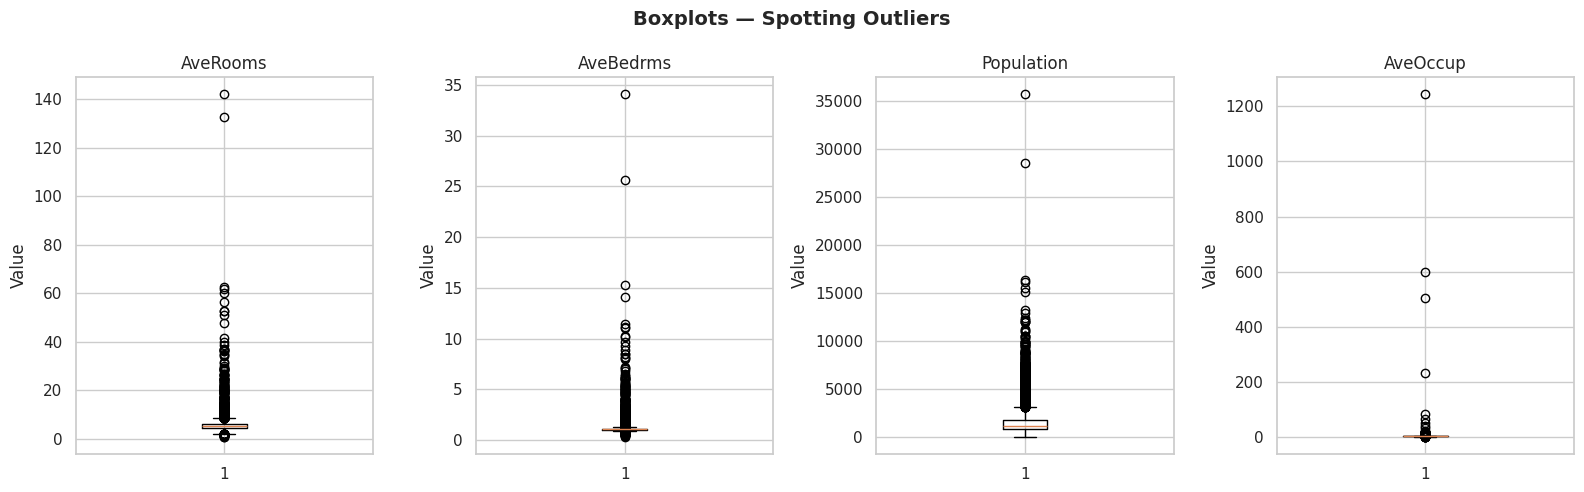

AveRooms        — max: 141.9, 99th percentile: 10.4
AveBedrms       — max: 34.1, 99th percentile: 2.1
Population      — max: 35682.0, 99th percentile: 5805.8
AveOccup        — max: 1243.3, 99th percentile: 5.4


In [5]:
# Boxplots show outliers as dots beyond the whiskers
# We focus on the columns most likely to have extreme values
suspicious_cols = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(suspicious_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Boxplots — Spotting Outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print the extreme values so we can decide what to keep
for col in suspicious_cols:
    print(f"{col:15s} — max: {df[col].max():.1f}, 99th percentile: {df[col].quantile(0.99):.1f}")

In [6]:
def remove_outliers_iqr(dataframe, columns, multiplier=3.0):
    """
    Remove rows where any of the specified columns have extreme outliers.

    multiplier=3.0 means we only remove truly extreme values (not just unusual ones)
    — we use 3.0 instead of the common 1.5 because housing data naturally varies a lot
    """
    df_clean = dataframe.copy()  # never modify the original dataframe
    total_removed = 0

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)  # 25th percentile
        Q3 = df_clean[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1                       # interquartile range

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Count how many rows will be removed for this column
        outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        n_removed = outlier_mask.sum()
        total_removed += n_removed

        # Keep only rows within bounds
        df_clean = df_clean[~outlier_mask]

        print(f"{col:15s} — bounds: [{lower_bound:.2f}, {upper_bound:.2f}] — removed: {n_removed} rows")

    print(f"\nTotal rows removed: {total_removed}")
    print(f"Rows before: {len(dataframe):,}  →  Rows after: {len(df_clean):,}")
    return df_clean

# Apply to the columns we saw had extreme outliers
cols_to_clean = ["AveRooms", "AveBedrms", "Population", "AveOccup"]
df_clean = remove_outliers_iqr(df, cols_to_clean)

AveRooms        — bounds: [-0.39, 10.89] — removed: 180 rows
AveBedrms       — bounds: [0.73, 1.37] — removed: 557 rows
Population      — bounds: [-2007.00, 4566.00] — removed: 413 rows
AveOccup        — bounds: [-0.11, 5.83] — removed: 101 rows

Total rows removed: 1251
Rows before: 20,640  →  Rows after: 19,389


In [7]:
print(f"Rows with capped target (value = 5.0): {(df_clean['MedHouseVal'] == 5.0).sum()}")

# Remove rows where house value is exactly 5.0 (the cap)
df_clean = df_clean[df_clean["MedHouseVal"] < 5.0]

print(f"Shape after removing capped values: {df_clean.shape}")

# Verify the cap is gone
print(f"New max house value: {df_clean['MedHouseVal'].max():.3f}")

Rows with capped target (value = 5.0): 27
Shape after removing capped values: (18440, 9)
New max house value: 4.991


In [9]:
# Separate features (X) from the target variable (y)
X = df_clean.drop(columns=["MedHouseVal"])  # everything except the target
y = df_clean["MedHouseVal"]                  # only the target

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# train_test_split randomly shuffles then splits the data
# random_state=42 means the split is reproducible — you get the same split every run
# This is critical in MLOps: teammates must be able to reproduce your exact results
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test set
    random_state=42     # fixed seed for reproducibility
)

print(f"\nTraining set:   {X_train.shape[0]:,} rows")
print(f"Test set:       {X_test.shape[0]:,} rows")
print(f"Train/Test ratio: {X_train.shape[0]/len(X)*100:.0f}% / {X_test.shape[0]/len(X)*100:.0f}%")


Features shape: (18440, 8)
Target shape:   (18440,)
Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training set:   14,752 rows
Test set:       3,688 rows
Train/Test ratio: 80% / 20%


In [10]:
# Initialize the scaler
scaler = StandardScaler()

# FIT on training data only — learns the mean and std of each feature from training set
# TRANSFORM applies the scaling: (value - mean) / std
X_train_scaled = scaler.fit_transform(X_train)

# ONLY TRANSFORM test data — use the training mean/std, not test mean/std
# This simulates real production: you scale new data using what you learned from training
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames so column names are preserved
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaling complete ✓")
print(f"\nBefore scaling — MedInc mean: {X_train['MedInc'].mean():.3f}, std: {X_train['MedInc'].std():.3f}")
print(f"After scaling  — MedInc mean: {X_train_scaled['MedInc'].mean():.3f}, std: {X_train_scaled['MedInc'].std():.3f}")
print(f"\nBefore scaling — Population mean: {X_train['Population'].mean():.1f}")
print(f"After scaling  — Population mean: {X_train_scaled['Population'].mean():.3f}")

Scaling complete ✓

Before scaling — MedInc mean: 3.688, std: 1.560
After scaling  — MedInc mean: -0.000, std: 1.000

Before scaling — Population mean: 1356.5
After scaling  — Population mean: 0.000


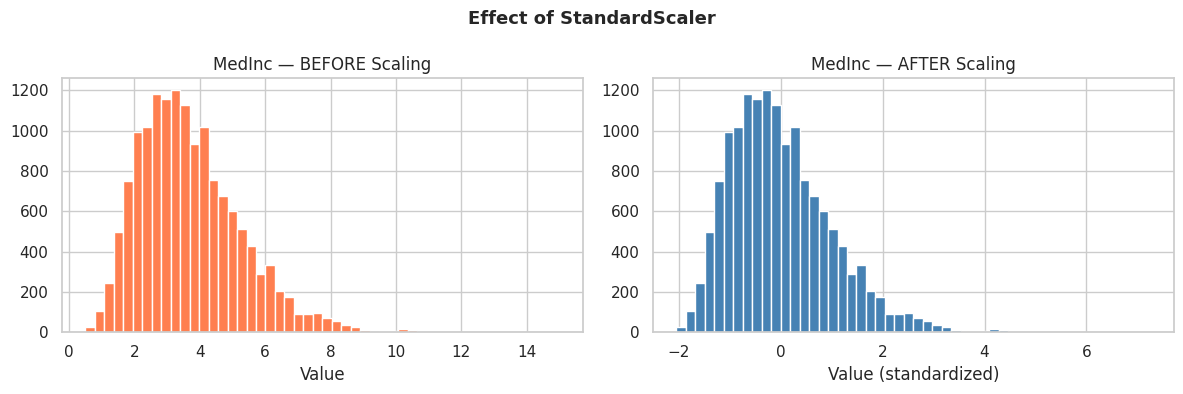

Shape is identical — scaling changes values but NOT the number of rows
Train scaled shape: (14752, 8)
Test scaled shape:  (3688, 8)


In [11]:
# Compare one feature before and after scaling side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train["MedInc"], bins=50, color="coral", edgecolor="white")
axes[0].set_title("MedInc — BEFORE Scaling")
axes[0].set_xlabel("Value")

axes[1].hist(X_train_scaled["MedInc"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("MedInc — AFTER Scaling")
axes[1].set_xlabel("Value (standardized)")

plt.suptitle("Effect of StandardScaler", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Shape is identical — scaling changes values but NOT the number of rows")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

In [13]:
# Save all 5 outputs we need for Day 3 (feature engineering) and Day 4 (training)
X_train_scaled.to_csv("X_train.csv", index=False)
X_test_scaled.to_csv("X_test.csv",  index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv",   index=False)
df_clean.to_csv("california_housing_clean.csv", index=False)

# Save the scaler using pickle so we can reuse it in predict.py (Day 6)
# In production, you always save the scaler alongside the model
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✓ Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("✓ Saved: california_housing_clean.csv")
print("✓ Saved: scaler.pkl")
print(f"\nFinal dataset summary:")
print(f"  Training samples:   {X_train_scaled.shape[0]:,}")
print(f"  Test samples:       {X_test_scaled.shape[0]:,}")
print(f"  Number of features: {X_train_scaled.shape[1]}")

✓ Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
✓ Saved: california_housing_clean.csv
✓ Saved: scaler.pkl

Final dataset summary:
  Training samples:   14,752
  Test samples:       3,688
  Number of features: 8


In [14]:
print("=" * 55)
print("DATA PREP SUMMARY — Ready for Day 3")
print("=" * 55)
print(f"""
CLEANING:
  • Removed outliers using IQR method (multiplier=3.0)
  • Removed capped target values (MedHouseVal = 5.0)
  • Final clean dataset: {df_clean.shape[0]:,} rows

SPLITTING:
  • Training set: {X_train.shape[0]:,} rows (80%)
  • Test set:     {X_test.shape[0]:,} rows (20%)
  • random_state=42 for full reproducibility

SCALING:
  • Applied StandardScaler to all 8 features
  • Scaler fitted on train only — applied to both sets
  • Scaler saved as scaler.pkl for reuse in prediction

FILES SAVED:
  • X_train.csv, X_test.csv (scaled features)
  • y_train.csv, y_test.csv (target values)
  • california_housing_clean.csv (full clean dataset)
  • scaler.pkl (fitted scaler object)

READY FOR DAY 3:
  • Feature engineering — create new features from existing ones
  • Add room-to-bedroom ratio, population density, income brackets
""")

DATA PREP SUMMARY — Ready for Day 3

CLEANING:
  • Removed outliers using IQR method (multiplier=3.0)
  • Removed capped target values (MedHouseVal = 5.0)
  • Final clean dataset: 18,440 rows

SPLITTING:
  • Training set: 14,752 rows (80%)
  • Test set:     3,688 rows (20%)
  • random_state=42 for full reproducibility

SCALING:
  • Applied StandardScaler to all 8 features
  • Scaler fitted on train only — applied to both sets
  • Scaler saved as scaler.pkl for reuse in prediction

FILES SAVED:
  • X_train.csv, X_test.csv (scaled features)
  • y_train.csv, y_test.csv (target values)
  • california_housing_clean.csv (full clean dataset)
  • scaler.pkl (fitted scaler object)

READY FOR DAY 3:
  • Feature engineering — create new features from existing ones
  • Add room-to-bedroom ratio, population density, income brackets

